# 0. Описание лабораторной работы

**Задание:**

- Взять любой датасет классификации изображений; сделать базовое описание выбранного датасета.
  - Желательно, чтобы датасет был похож по разметке на тот, который использовался в 10-й лабораторной работе.
  - Если в датасете много классов, можно самостоятельно ограничить их количество или удалить часть классов, но должно остаться не менее 5 классов.
  - Для упрощения обучения рекомендуется использовать датасет с изображениями небольшого размера или самостоятельно уменьшить размер изображений.

- Реализовать с нуля все компоненты архитектуры **ViT трансформера** или **Swin трансформера**.

- Реализовать полный пайплайн обучения и обучить модель классификации изображений.
- Продемонстрировать результаты обучения (точность, потери, визуализации).

- Дообучить текстовую модель из 10-й лабораторной работы и модель, полученную в данной лабораторной с использованием метода **контрастного обучения**.
- Продемонстрировать возможность **zero-shot классификации** и сравнить эмбеддинги, полученные двумя моделями.

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import plotly.io as pio
import plotly.express as px
pio.templates.default = 'plotly_white'
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np
import random
import sklearn
import torch
from torch import nn
import os
import io

seed = 42
random.seed(seed)
np.random.seed(seed)
sklearn.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# 1. Подготовка данных



**Fashion-MNIST** — это набор данных, содержащий изображения статей Zalando. Он состоит из обучающего набора (60 000 примеров) и тестового набора (10 000 примеров). Каждый пример представляет собой полутоновое изображение размером 28x28 пикселей, связанное с меткой одного из 10 классов. Набор данных предназначен для прямого использования в качестве замены оригинального набора MNIST для тестирования алгоритмов машинного обучения, сохраняя тот же размер изображения и структуру разделения.

**Метки классов:**


| Метка | Описание класса |
| :----: | :-------: |
| 0     | T-shirt/top |
| 1     | Trouser |
| 2     | Pullover |
| 3     | Dress |
| 4     | Coat |
| 5     | Sandal |
| 6     | Shirt |
| 7     | Sneaker |
| 8     | Bag |
| 9     | Ankle boot |


In [ ]:
from datasets import load_dataset
dataset = load_dataset("zalando-datasets/fashion_mnist")

README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
def visualize_fashion_mnist(data_subset, num_samples=100, split="train"):
    indices = random.sample(range(len(data_subset)), min(num_samples, len(data_subset)))
    rows, cols = int(np.ceil(num_samples / 10)), min(num_samples, 10)

    fig = make_subplots(rows=rows, cols=cols)

    for idx, sample_idx in enumerate(indices):
        row, col = idx // cols + 1, idx % cols + 1

        sample = data_subset[sample_idx]
        image = np.array(sample['image'])
        label = sample['label']
        image = np.stack([image, image, image], axis=2)

        hovertemplate = f'Label: {label}<extra></extra>'
        fig.add_trace(go.Image(z=image, hovertemplate=hovertemplate), row=row, col=col)

    fig.update_layout(height=100 * rows, width=100 * cols)
    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)
    fig.update_layout(showlegend=False)

    return fig

visualize_fashion_mnist(dataset['train']).show()

In [ ]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

class FashionDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item['image']
        label = item['label']
        image_tensor = self.transform(image.convert('L'))
        return {'image': image_tensor, 'label': torch.tensor(label)}

In [ ]:
train_dataset = FashionDataset(dataset['train'])
test_dataset = FashionDataset(dataset['test'])

def collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    labels = torch.stack([item['label'] for item in batch])
    return {'image': images, 'label': labels}

train_loader_img = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True
)

test_loader_img = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

sample_batch = next(iter(train_loader_img))
print(f"Batch image shape: {sample_batch['image'].shape}")
print(f"Batch label shape: {sample_batch['label'].shape}")
print(f"Image range: [{sample_batch['image'].min():.3f}, {sample_batch['image'].max():.3f}]")

Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])
Image range: [0.000, 1.000]


# 2. Реализации attention

Реализация синусоидального позиционного кодирования для трансформеров.
    
Класс добавляет информацию о позиции токенов в последовательности к их эмбеддингам. Используется синусоидальная функция для четных индексов и косинусоидальная для нечетных, что позволяет модели обучать относительные позиции.
    
Основные характеристики:
- Позиционные эмбеддинг зависят от позиции токена в последовательности
- Частота кодирования уменьшается экспоненциально по размерности эмбеддинга
- Поддерживаются последовательности переменной длины с кэшированием

Используется формула из оригинальной статьи "Attention Is All You Need":
$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right), \quad\quad
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

In [ ]:
class CustomPositionalEncoding(nn.Module):
    def __init__(self, embedding_dim, max_sequence_length=512, base_frequency=10000.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.base_frequency = base_frequency
        self.max_sequence_length = max_sequence_length
        self._cached_encodings = {}

    def _compute_encoding(self, sequence_length):
        if sequence_length not in self._cached_encodings:
            position_indices = torch.arange(sequence_length).unsqueeze(1)

            frequency_scaling = torch.exp(
                torch.arange(0, self.embedding_dim, 2) *
                (-torch.log(torch.tensor(self.base_frequency)) / self.embedding_dim)
            )

            encoding = torch.zeros(sequence_length, self.embedding_dim)
            encoding[:, 0::2] = torch.sin(position_indices * frequency_scaling)
            encoding[:, 1::2] = torch.cos(position_indices * frequency_scaling)
            self._cached_encodings[sequence_length] = encoding

        return self._cached_encodings[sequence_length]

    def forward(self, token_embeddings):
        sequence_length = token_embeddings.size(1)

        if sequence_length > self.max_sequence_length:
            raise ValueError(f"Sequence length {sequence_length} is greater than limit {self.max_sequence_length}")

        encoding = self._compute_encoding(sequence_length)
        encoding_with_batch = encoding.unsqueeze(0).to(token_embeddings.device)
        return token_embeddings + encoding_with_batch

Формула Multi-Head Attention:
$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O
$$

$$
\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Обозначения:
- $ Q, K, V $ — матрицы запросов (queries), ключей (keys) и значений (values)
- $ d_k $ — размерность ключей (head_dimension)
- $ h $ — количество голов механизма внимания (num_heads)
- $ W_i^Q, W_i^K, W_i^V $ — матрицы проекции для i-й головы
- $ W^O $ — итоговая матрица проекции


Масштабирование на $ \sqrt{d_k} $ предотвращает слишком маленькие градиенты

In [ ]:
class CustomMultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        self.head_dimension = hidden_size // num_heads
        self.num_heads = num_heads
        self.hidden_size = hidden_size
        self.query_projection = nn.Linear(hidden_size, hidden_size)
        self.key_projection = nn.Linear(hidden_size, hidden_size)
        self.value_projection = nn.Linear(hidden_size, hidden_size)
        self.output_projection = nn.Linear(hidden_size, hidden_size)

    def _reshape_for_attention(self, tensor):
        batch_size, sequence_length, hidden_size = tensor.shape
        return tensor.reshape(batch_size, sequence_length, self.num_heads, self.head_dimension).transpose(1, 2)

    def forward(self, input_sequence, attention_mask=None):
        batch_size, sequence_length, hidden_size = input_sequence.size()

        queries = self._reshape_for_attention(self.query_projection(input_sequence))
        keys = self._reshape_for_attention(self.key_projection(input_sequence))
        values = self._reshape_for_attention(self.value_projection(input_sequence))

        attention_scores = torch.matmul(queries, keys.transpose(-2, -1))
        attention_scores = attention_scores / torch.sqrt(torch.tensor(self.head_dimension, dtype=torch.float32))

        if attention_mask is not None:
            attention_scores = attention_scores.masked_fill(attention_mask[:, None, None, :] == 0, float('-inf'))

        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_weights, values)
        attention_output = attention_output.transpose(1, 2)
        attention_output = attention_output.reshape(batch_size, sequence_length, hidden_size)
        return self.output_projection(attention_output)

### Transformer Encoder Layer

**Переменные:**
- `hidden_size` : Размерность эмбеддингов токенов (например, 512, 768)
- `num_heads`: Количество голов внимания в multi-head attention
- `feedforward_dimension`: Размерность скрытого слоя в feed-forward сети (обычно 4×hidden_size)
- `dropout_rate`: Вероятность dropout для регуляризации

**Компоненты слоя:**
1. Self Attention Block:
   - `self_attention`: Multi-head self-attention механизм
   - Вычисляет зависимости между всеми токенами последовательности

2. Feed-forward Network:
   - `feedforward_network`: Двухслойный персептрон с ReLU активацией
   - Применяется к каждому токену независимо

3. Layer Normalization:
   - `pre_attention_layer_norm`: Нормализация перед блоком внимания
   - `pre_feedforward_layer_norm`: Нормализация перед feed-forward сетью

4. Residual Connections:
   - Добавление выхода каждого блока к его входу
   - Помогает градиентам распространяться в глубоких сетях

In [ ]:
class CustomTransformerEncoderLayer(nn.Module):
    def __init__(self, hidden_size, num_heads, feedforward_dimension, dropout_rate=0.1):
        super().__init__()

        self.self_attention_block = nn.ModuleDict({
            'attention': CustomMultiHeadAttention(hidden_size, num_heads),
            'layer_norm': nn.LayerNorm(hidden_size),
            'dropout': nn.Dropout(dropout_rate)
        })

        self.feedforward_block = nn.ModuleDict({
            'linear_1': nn.Linear(hidden_size, feedforward_dimension),
            'activation': nn.ReLU(),
            'linear_2': nn.Linear(feedforward_dimension, hidden_size),
            'layer_norm': nn.LayerNorm(hidden_size),
            'dropout': nn.Dropout(dropout_rate)
        })

    def _apply_residual_block(self, input_tensor, block_output, layer_norm, dropout):
        residual_connection = input_tensor + dropout(block_output)
        return layer_norm(residual_connection)

    def forward(self, input_sequence, attention_mask=None):
        attention_output = self.self_attention_block['attention'](input_sequence, attention_mask)
        normalized_attention_output = self._apply_residual_block(
            input_sequence,
            attention_output,
            self.self_attention_block['layer_norm'],
            self.self_attention_block['dropout']
        )

        feedforward_hidden = self.feedforward_block['linear_1'](normalized_attention_output)
        feedforward_hidden = self.feedforward_block['activation'](feedforward_hidden)
        feedforward_output = self.feedforward_block['linear_2'](feedforward_hidden)

        final_output = self._apply_residual_block(
            normalized_attention_output,
            feedforward_output,
            self.feedforward_block['layer_norm'],
            self.feedforward_block['dropout']
        )

        return final_output

### TransformerEncoder

**Назначение:**
Стек из нескольких идентичных слоев Transformer Encoder для последовательной обработки входной последовательности.

**Аргументы конструктора:**
- `num_layers` (int): Количество слоев энкодера в стеке (обычно 6-12 для базовых моделей)
- `hidden_size` (int): Размерность эмбеддингов (например, 512, 768)
- `num_heads` (int): Количество голов внимания в каждом слое
- `feedforward_dimension` (int): Размерность скрытого слоя в feed-forward сети
- `dropout_rate` (float, optional=0.1): Вероятность dropout для регуляризации
- `apply_final_norm` (bool, optional=True): Применять ли финальную LayerNorm

**Основные компоненты:**
1. **Стек слоев энкодера** (`encoder_layers`):
   - Список из `num_layers` идентичных `CustomTransformerEncoderLayer`
   - Каждый слой содержит self-attention и feed-forward блоки

2. **Финальная нормализация** (`final_layer_norm`):
   - Опциональная LayerNorm после всех слоев
   - Стабилизирует выход для следующих компонентов модели

**Forward метод:**
- `input_sequence`: Входные эмбеддинги токенов `[batch_size, sequence_length, hidden_size]`
- `attention_mask`: Маска внимания для padding или causal masking
- `return_all_layers`: Возвращать выходы всех слоев или только последнего

**Режимы работы:**
1. **Обычный режим** (`return_all_layers=False`):
   - Возвращает только выход последнего слоя
   - Эффективно по памяти

2. **Расширенный режим** (`return_all_layers=True`):
   - Возвращает кортеж `(final_output, layer_outputs)`
   - `layer_outputs` содержит выходы каждого слоя
   - Полезно для анализа или промежуточных представлений

In [ ]:
class CustomTransformerEncoder(nn.Module):
    def __init__(self, num_layers, hidden_size, num_heads, feedforward_dimension,
                 dropout_rate=0.1, apply_final_norm=True):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.apply_final_norm = apply_final_norm

        self.encoder_layers = nn.ModuleList([
            CustomTransformerEncoderLayer(
                hidden_size=hidden_size,
                num_heads=num_heads,
                feedforward_dimension=feedforward_dimension,
                dropout_rate=dropout_rate
            )
            for layer_idx in range(num_layers)
        ])

        if apply_final_norm:
            self.final_layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, input_sequence, attention_mask=None, return_all_layers=False):
        if return_all_layers:
            layer_outputs = []
            current_sequence = input_sequence

            for layer_idx, encoder_layer in enumerate(self.encoder_layers):
                current_sequence = encoder_layer(current_sequence, attention_mask)
                layer_outputs.append(current_sequence)

            if self.apply_final_norm:
                current_sequence = self.final_layer_norm(current_sequence)
                layer_outputs[-1] = current_sequence

            return current_sequence, layer_outputs
        else:
            encoder_output = input_sequence

            for encoder_layer in self.encoder_layers:
                encoder_output = encoder_layer(encoder_output, attention_mask)

            if self.apply_final_norm:
                encoder_output = self.final_layer_norm(encoder_output)

            return encoder_output

In [ ]:
class CustomTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, emb_dim=256,
                 num_layers=6, num_heads=8, ff_dim=1024, dropout=0.1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.pos = CustomPositionalEncoding(emb_dim)
        self.encoder = CustomTransformerEncoder(num_layers=num_layers,
                                                hidden_size=emb_dim,
                                                num_heads=num_heads,
                                                feedforward_dimension=ff_dim,
                                                dropout_rate=dropout)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.head = nn.Linear(emb_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x: [batch, seq_len]
        emb = self.emb(x)  # [batch, seq_len, emb_dim]
        # add CLS token
        batch_size = x.size(0)
        cls = self.cls_token.expand(batch_size, -1, -1)
        emb = torch.cat([cls, emb], dim=1)  # [batch, seq_len+1, emb_dim]

        if mask is not None:
            cls_mask = torch.ones(batch_size, 1, device=mask.device)
            mask = torch.cat([cls_mask, mask], dim=1)  # [batch, seq_len+1]
        emb = self.pos(emb)
        encoded = self.encoder(emb, mask)
        cls_out = encoded[:, 0, :]  # [batch, emb_dim]
        cls_out = self.dropout(cls_out)
        return self.head(cls_out)  # [batch, num_classes]

# 3. ViT

In [ ]:
class ViTPatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=128):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_encoder = CustomPositionalEncoding(embed_dim, max_sequence_length=self.n_patches+1)

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.proj(x)  # [B, 1, 28, 28] -> [B, embed_dim, 7, 7]
        x = x.flatten(2)  # [B, embed_dim, 7, 7] -> [B, embed_dim, 49]
        x = x.transpose(1, 2)  # [B, embed_dim, 49] -> [B, 49, embed_dim]

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # [B, 50, embed_dim]
        x = self.pos_encoder(x)
        return x

In [ ]:
class ViTClassifier(nn.Module):
    def __init__(self, img_size=28, patch_size=4, in_channels=1, num_classes=10,
                 embed_dim=128, num_layers=4, num_heads=4, ff_dim=512, dropout=0.1):
        super().__init__()

        self.patch_embed = ViTPatchEmbedding(img_size, patch_size, in_channels, embed_dim)

        self.encoder = CustomTransformerEncoder(
            num_layers=num_layers,
            hidden_size=embed_dim,
            num_heads=num_heads,
            feedforward_dimension=ff_dim,
            dropout_rate=dropout,
            apply_final_norm=True
        )

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

        self.projection_head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x, return_embeddings=False, return_projection=False):
        x = self.patch_embed(x)  # [B, 50, embed_dim]
        x = self.encoder(x)  # [B, 50, embed_dim]
        cls_token = x[:, 0]  # [B, embed_dim]

        if return_projection:  # contrastive train
            return F.normalize(self.projection_head(cls_token), dim=1)

        if return_embeddings:
            return cls_token

        return self.head(cls_token)

## Обучение ViT

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model = ViTClassifier(
    img_size=28,
    patch_size=4,
    in_channels=1,
    num_classes=10,
    embed_dim=128,
    num_layers=4,
    num_heads=4,
    ff_dim=512,
    dropout=0.1
).to(device)

In [ ]:
from tqdm import tqdm

def train_vit_model(model, train_loader, test_loader, num_epochs=10, lr=3e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for batch in pbar:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({'loss': loss.item(), 'acc': 100. * correct / total})

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in test_loader:
                images = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        val_acc = 100. * val_correct / val_total
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss / len(test_loader))
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    return model, history

In [ ]:
trained_vit_model, history = train_vit_model(vit_model, train_loader_img, test_loader_img, num_epochs=10)

Epoch 1/10: 100%|██████████| 937/937 [00:40<00:00, 22.94it/s, loss=0.487, acc=72.5]


Epoch 1: Train Acc: 72.50%, Val Acc: 81.51%


Epoch 2/10: 100%|██████████| 937/937 [00:40<00:00, 23.38it/s, loss=0.44, acc=83.2]


Epoch 2: Train Acc: 83.22%, Val Acc: 84.84%


Epoch 3/10: 100%|██████████| 937/937 [00:40<00:00, 23.36it/s, loss=0.375, acc=85.2]


...

Epoch 8: Train Acc: 88.97%, Val Acc: 87.32%


Epoch 9/10: 100%|██████████| 937/937 [00:40<00:00, 22.95it/s, loss=0.352, acc=89.5]


Epoch 9: Train Acc: 89.48%, Val Acc: 87.89%


Epoch 10/10: 100%|██████████| 937/937 [00:40<00:00, 22.90it/s, loss=0.227, acc=89.9]


Epoch 10: Train Acc: 89.86%, Val Acc: 88.24%


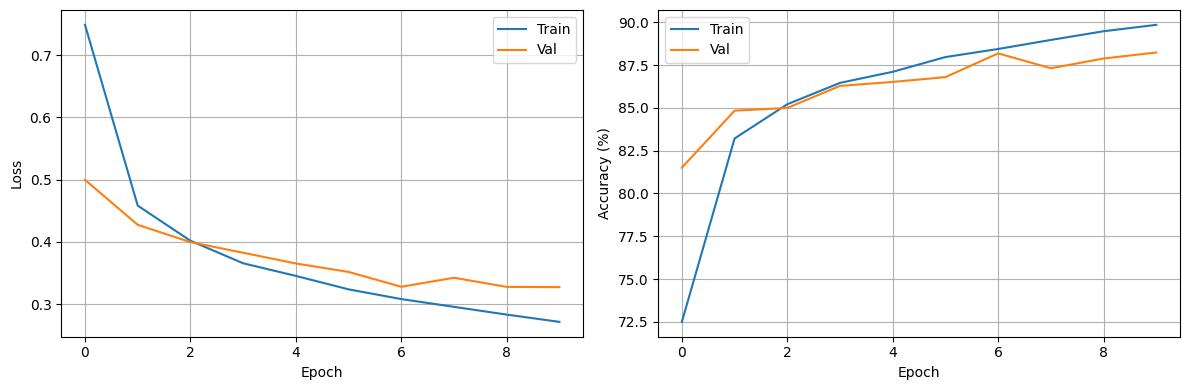

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

## Обучение с помощью contrastive learning

In [ ]:
import requests
import io
import torch
import torch.nn as nn

github_url = 'https://raw.githubusercontent.com/Lopa10ko/itmo-ml-2025/main/lab-10/text_model.pth'
response = requests.get(github_url)
response.raise_for_status()
model_bytes = io.BytesIO(response.content)

def load_text_model():
    text_model = torch.load(model_bytes, map_location=device, weights_only=False)
    print(f"Loaded object type: {type(text_model)}")
    text_model.to(device)

    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

    print(f"Model params: {sum(p.numel() for p in text_model.parameters()) / 1e6:.2f}M")
    return text_model, tokenizer

text_model, tokenizer = load_text_model()

Loaded object type: <class '__main__.CustomTransformerClassifier'>
Model params: 4.70M


In [ ]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

In [ ]:
import torch.nn.functional as F

class ImageEncoderCLIP(nn.Module):
    def __init__(self, vit_model, projection_dim=128):
        super().__init__()
        self.vit = vit_model
        self.image_projection = nn.Sequential(
            nn.Linear(10, 512),  # ViT 10 classes -> 512
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        image_features = self.vit(x)
        return F.normalize(self.image_projection(image_features), dim=-1)

    def get_features(self, x):
        return self.vit(x)

class TextEncoderCLIP(nn.Module):
    def __init__(self, text_model, projection_dim=128):
        super().__init__()
        self.text_model = text_model
        self.text_projection = nn.Sequential(
            nn.Linear(2, 512),  # text 2 classes (neg/pos) -> 512
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, input_ids, attention_mask=None):
        text_features = self.text_model(input_ids, attention_mask)
        return F.normalize(self.text_projection(text_features), dim=-1)

    def encode_text(self, texts, tokenizer, device):
        self.eval()
        with torch.no_grad():
            encodings = tokenizer(
                texts,
                truncation=True,
                padding=True,
                max_length=256,
                return_tensors='pt'
            ).to(device)
            return self(encodings['input_ids'], encodings['attention_mask'])

In [ ]:
class CLIPModel(nn.Module):
    def __init__(self, image_encoder, text_encoder, temperature=0.07):
        super().__init__()
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.temperature = nn.Parameter(torch.tensor([temperature]))
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / temperature))

    def forward(self, images, input_ids, attention_mask=None):
        image_features = self.image_encoder(images)
        text_features = self.text_encoder(input_ids, attention_mask)

        image_features = F.normalize(image_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)

        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.T
        logits_per_text = logits_per_image.T

        return logits_per_image, logits_per_text

    def encode_image(self, images):
        return self.image_encoder(images)

    def encode_text(self, texts, tokenizer, device):
        return self.text_encoder.encode_text(texts, tokenizer, device)

def clip_loss(logits_per_image, logits_per_text, labels):
    batch_size = logits_per_image.shape[0]

    # Image-to-text loss
    loss_i2t = F.cross_entropy(logits_per_image, labels)

    # Text-to-image loss
    loss_t2i = F.cross_entropy(logits_per_text, labels)

    return (loss_i2t + loss_t2i) / 2

In [ ]:
def prepare_clip_data(images, labels, tokenizer, num_captions_per_image=1):
    batch_size = len(images)

    texts = []
    text_labels = []

    for label in labels:
        class_idx = label.item()
        class_name = class_names[class_idx]

        captions = [
            f"a photo of a {class_name}",
            f"a picture of {class_name}",
            f"an image showing {class_name}",
            f"{class_name} in a photo",
            f"photo: {class_name}"
        ]

        selected_captions = np.random.choice(
            captions,
            size=num_captions_per_image,
            replace=False if len(captions) >= num_captions_per_image else True
        )

        texts.extend(selected_captions)
        text_labels.extend([class_idx] * num_captions_per_image)

    text_encodings = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=256,
        return_tensors='pt'
    )

    return {
        'images': images,
        'input_ids': text_encodings['input_ids'],
        'attention_mask': text_encodings['attention_mask'],
        'labels': torch.arange(batch_size * num_captions_per_image // num_captions_per_image)
    }

class CLIPDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, tokenizer, num_captions=1):
        self.dataset = base_dataset
        self.tokenizer = tokenizer
        self.num_captions = num_captions

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']
        label = item['label'].item()
        class_name = class_names[label]

        captions = [
            f"a photo of a {class_name}",
            f"a picture of {class_name}",
            f"an image showing {class_name}",
            f"{class_name} in a photo",
            f"photo: {class_name}"
        ]

        selected_idx = np.random.randint(0, len(captions), size=self.num_captions)
        selected_captions = [captions[i] for i in selected_idx]

        encodings = self.tokenizer(
            selected_captions[0],
            truncation=True,
            padding='max_length',
            max_length=256,
            return_tensors='pt'
        )

        return {
            'image': image,
            'input_ids': encodings['input_ids'].squeeze(),
            'attention_mask': encodings['attention_mask'].squeeze(),
            'label': label,
            'text': selected_captions[0]
        }

def clip_collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([torch.tensor(item['label']) for item in batch])

    return {
        'images': images,
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

clip_train_dataset = CLIPDataset(train_dataset, tokenizer, num_captions=1)
clip_test_dataset = CLIPDataset(test_dataset, tokenizer, num_captions=1)

clip_train_loader = torch.utils.data.DataLoader(
    clip_train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=clip_collate_fn,
    drop_last=True
)

clip_test_loader = torch.utils.data.DataLoader(
    clip_test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=clip_collate_fn
)

In [ ]:
image_encoder = ImageEncoderCLIP(trained_vit_model, projection_dim=128)
text_encoder = TextEncoderCLIP(text_model, projection_dim=128)
clip_model = CLIPModel(image_encoder, text_encoder).to(device)

test_batch = next(iter(clip_train_loader))
test_images = test_batch['images'].to(device)
test_input_ids = test_batch['input_ids'].to(device)
test_attention_mask = test_batch['attention_mask'].to(device)

with torch.no_grad():
    logits_i, logits_t = clip_model(test_images, test_input_ids, test_attention_mask)
    print(f"Image features shape: {clip_model.encode_image(test_images).shape}")
    print(f"Text features shape: {clip_model.encode_text(['test'], tokenizer, device).shape}")
    print(f"Logits per image: {logits_i.shape}")
    print(f"Logits per text: {logits_t.shape}")

def train_clip_model(model, train_loader, val_loader, num_epochs=5, lr=1e-4):
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        batch_count = 0

        pbar = tqdm(train_loader, desc=f'CLIP Epoch {epoch+1}/{num_epochs}')
        for batch in pbar:
            images = batch['images'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = torch.arange(len(images), device=device)

            logits_per_image, logits_per_text = model(images, input_ids, attention_mask)
            loss = clip_loss(logits_per_image, logits_per_text, labels)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_train_loss += loss.item()
            batch_count += 1

            pbar.set_postfix({'loss': loss.item()})

        avg_train_loss = epoch_train_loss / batch_count
        train_losses.append(avg_train_loss)

        model.eval()
        epoch_val_loss = 0
        val_batch_count = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['images'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = torch.arange(len(images), device=device)

                logits_per_image, logits_per_text = model(images, input_ids, attention_mask)
                loss = clip_loss(logits_per_image, logits_per_text, labels)

                epoch_val_loss += loss.item()
                val_batch_count += 1

        avg_val_loss = epoch_val_loss / val_batch_count
        val_losses.append(avg_val_loss)

        scheduler.step()

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
        print(f"  Logit scale: {model.logit_scale.exp().item():.4f}")


    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('CLIP Training Loss')
    plt.legend()
    plt.grid(True)

    return model, train_losses, val_losses

Image features shape: torch.Size([64, 128])
Text features shape: torch.Size([1, 128])
Logits per image: torch.Size([64, 64])
Logits per text: torch.Size([64, 64])


CLIP Epoch 1/5: 100%|██████████| 937/937 [01:55<00:00,  8.14it/s, loss=4.09]


Epoch 1: Train Loss = 4.1271, Val Loss = 4.0935
  Logit scale: 14.2605


CLIP Epoch 2/5: 100%|██████████| 937/937 [01:59<00:00,  7.86it/s, loss=4.14]


Epoch 2: Train Loss = 4.1160, Val Loss = 4.0760
  Logit scale: 14.2251


CLIP Epoch 3/5: 100%|██████████| 937/937 [01:41<00:00,  9.27it/s, loss=4.14]


Epoch 3: Train Loss = 4.1130, Val Loss = 4.0798
  Logit scale: 14.1786


CLIP Epoch 4/5: 100%|██████████| 937/937 [01:41<00:00,  9.25it/s, loss=4.12]


Epoch 4: Train Loss = 4.1104, Val Loss = 4.0731
  Logit scale: 14.1596


CLIP Epoch 5/5: 100%|██████████| 937/937 [01:42<00:00,  9.18it/s, loss=4.14]


Epoch 5: Train Loss = 4.1103, Val Loss = 4.0713
  Logit scale: 14.1561


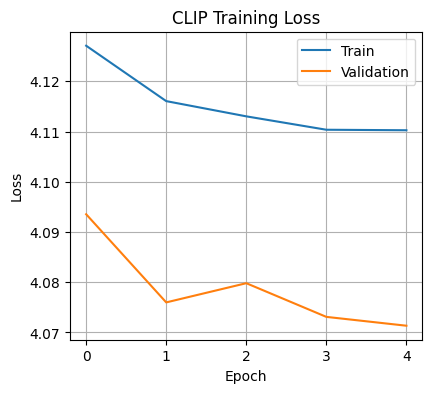

In [ ]:
trained_clip_model, train_losses, val_losses = train_clip_model(
    clip_model,
    clip_train_loader,
    clip_test_loader,
    num_epochs=5
)

## Zero-shot classification

In [ ]:
def clip_zero_shot_classification(clip_model, test_loader, tokenizer, device):
    clip_model.eval()
    class_prompts = []
    for class_name in class_names:
        prompts = [
            f"a photo of a {class_name}",
            f"a picture of {class_name}",
            f"an image of {class_name}",
            f"{class_name} in a photo",
            f"photo: {class_name}"
        ]
        class_prompts.append(prompts)

    all_text_features = []

    with torch.no_grad():
        for prompts in class_prompts:
            prompt_features = clip_model.encode_text(prompts, tokenizer, device)
            avg_features = prompt_features.mean(dim=0, keepdim=True)
            all_text_features.append(avg_features)

    all_text_features = torch.cat(all_text_features, dim=0)
    print(f"Text features shape: {all_text_features.shape}")

    all_predictions = []
    all_labels = []
    all_confidences = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="CLIP Zero-shot")
        for batch in pbar:
            images = batch['images'].to(device)
            labels = batch['labels'].cpu()

            image_features = clip_model.encode_image(images)

            image_features = F.normalize(image_features, dim=-1)
            text_features = F.normalize(all_text_features, dim=-1)

            logit_scale = clip_model.logit_scale.exp()
            similarity = logit_scale * image_features @ text_features.T

            confidences, predictions = similarity.max(dim=1)

            all_predictions.append(predictions.cpu())
            all_labels.append(labels)
            all_confidences.append(confidences.cpu())

            batch_acc = (predictions.cpu() == labels).float().mean().item()
            pbar.set_postfix({'acc': f'{batch_acc:.3f}'})

    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)
    all_confidences = torch.cat(all_confidences)

    accuracy = (all_predictions == all_labels).float().mean().item()

    print(f"CLIP Zero-shot Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    from sklearn.metrics import classification_report, confusion_matrix

    print("\nClassification Report:")
    print(classification_report(
        all_labels.numpy(),
        all_predictions.numpy(),
        target_names=class_names
    ))

    cm = confusion_matrix(all_labels.numpy(), all_predictions.numpy())

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names, yticklabels=class_names,
           title=f'CLIP Zero-shot Confusion Matrix\nAccuracy: {accuracy*100:.2f}%',
           ylabel='True label',
           xlabel='Predicted label')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

    return accuracy, all_predictions, all_labels, all_text_features

Text features shape: torch.Size([10, 128])


CLIP Zero-shot: 100%|██████████| 157/157 [00:11<00:00, 13.73it/s, acc=0.188]


CLIP Zero-shot Accuracy: 0.3862 (38.62%)

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.42      0.65      0.51      1000
     Trouser       0.38      0.80      0.52      1000
    Pullover       0.39      0.75      0.51      1000
       Dress       0.56      0.06      0.11      1000
        Coat       0.29      0.14      0.19      1000
      Sandal       0.25      0.00      0.00      1000
       Shirt       0.17      0.04      0.06      1000
     Sneaker       0.74      0.45      0.56      1000
         Bag       0.06      0.01      0.02      1000
  Ankle boot       0.35      0.95      0.51      1000

    accuracy                           0.39     10000
   macro avg       0.36      0.39      0.30     10000
weighted avg       0.36      0.39      0.30     10000



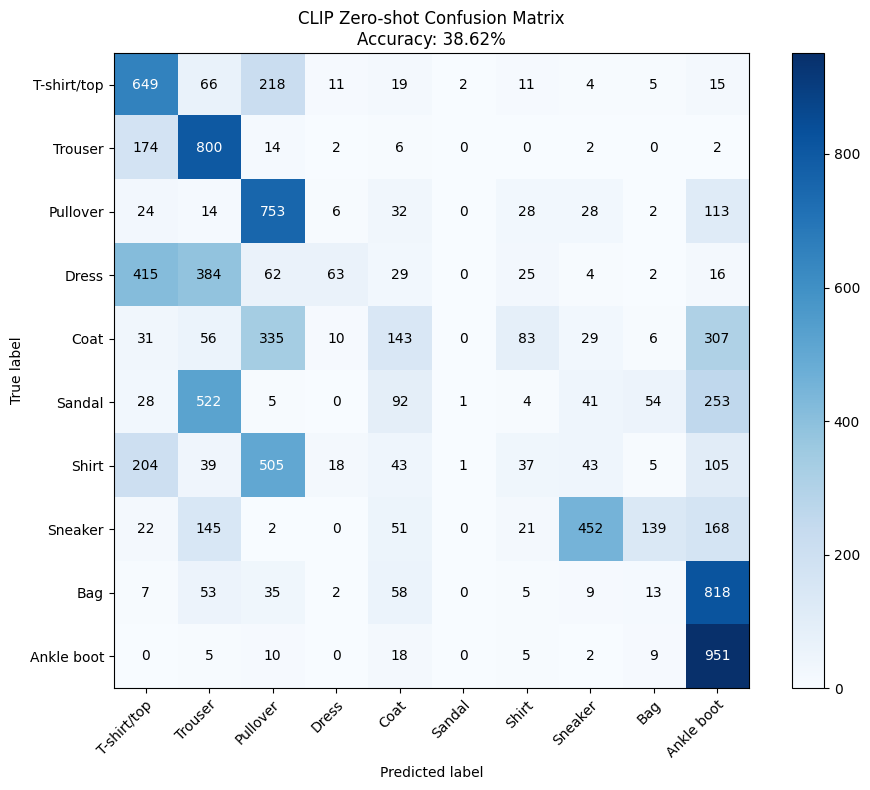

In [ ]:
clip_accuracy, clip_predictions, clip_labels, text_features = clip_zero_shot_classification(
    trained_clip_model,
    clip_test_loader,
    tokenizer,
    device
)

In [ ]:
def visualize_clip_embeddings(clip_model, test_loader, tokenizer, device, num_samples=200):
    clip_model.eval()
    image_embeddings = []
    text_embeddings = []
    labels_list = []

    print(f"Collecting {num_samples} samples...")

    with torch.no_grad():
        all_indices = list(range(len(test_loader.dataset)))
        np.random.shuffle(all_indices)
        selected_indices = all_indices[:num_samples]

        for idx in tqdm(selected_indices):
            item = test_loader.dataset[idx]
            image = item['image'].unsqueeze(0).to(device)
            label = item['label']
            class_name = class_names[label]
            img_emb = clip_model.encode_image(image)
            image_embeddings.append(img_emb.cpu())
            prompts = [
                f"a photo of a {class_name}",
                f"a picture of {class_name}"
            ]
            txt_embs = clip_model.encode_text(prompts, tokenizer, device)
            avg_txt_emb = txt_embs.mean(dim=0, keepdim=True)
            text_embeddings.append(avg_txt_emb.cpu())

            labels_list.append(label)

    image_embeddings = torch.cat(image_embeddings, dim=0).numpy()
    text_embeddings = torch.cat(text_embeddings, dim=0).numpy()
    labels = np.array(labels_list)

    print(f"Image embeddings: {image_embeddings.shape}")
    print(f"Text embeddings: {text_embeddings.shape}")

    from sklearn.manifold import TSNE
    all_embeddings = np.vstack([image_embeddings, text_embeddings])
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
    all_embeddings_2d = tsne.fit_transform(all_embeddings)

    image_2d = all_embeddings_2d[:num_samples]
    text_2d = all_embeddings_2d[num_samples:]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    scatter1 = axes[0].scatter(image_2d[:, 0], image_2d[:, 1], c=labels, cmap='tab10', alpha=0.6, s=30)
    axes[0].set_title('Image Embeddings by Class')
    axes[0].set_xlabel('t-SNE 1')
    axes[0].set_ylabel('t-SNE 2')
    axes[0].grid(True, alpha=0.3)

    scatter2 = axes[1].scatter(text_2d[:, 0], text_2d[:, 1], c=labels, cmap='tab10', alpha=0.6, s=30, marker='s')
    axes[1].set_title('Text Embeddings by Class')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].grid(True, alpha=0.3)

    colors = plt.cm.tab10(labels / 10.0)
    for i in range(min(20, num_samples)):
        axes[2].plot([image_2d[i, 0], text_2d[i, 0]],
                    [image_2d[i, 1], text_2d[i, 1]],
                    color=colors[i], alpha=0.3, linewidth=1)

    axes[2].scatter(image_2d[:, 0], image_2d[:, 1], c=labels, cmap='tab10',
                   alpha=0.6, s=30, label='Images')
    axes[2].scatter(text_2d[:, 0], text_2d[:, 1], c=labels, cmap='tab10',
                   alpha=0.6, s=30, marker='s', label='Texts')

    axes[2].set_title('CLIP Embedding Alignment')
    axes[2].set_xlabel('t-SNE 1')
    axes[2].set_ylabel('t-SNE 2')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.colorbar(scatter1, ax=axes[0], ticks=range(10))
    plt.colorbar(scatter2, ax=axes[1], ticks=range(10))
    plt.tight_layout()
    plt.show()

    from scipy.spatial.distance import cdist

    similarities = 1 - cdist(image_embeddings, text_embeddings, metric='cosine')
    diagonal = np.diag(similarities)

    print(f"Cross-modal Similarity Statistics:")
    print(f"Mean similarity (matching pairs): {diagonal.mean():.4f}")
    print(f"Std similarity (matching pairs): {diagonal.std():.4f}")
    print(f"Min similarity: {diagonal.min():.4f}")
    print(f"Max similarity: {diagonal.max():.4f}")

    print(f"Similarity by Class:")
    for class_idx in range(10):
        mask = labels == class_idx
        if mask.sum() > 0:
            class_sim = diagonal[mask]
            print(f"- {class_names[class_idx]:<15}: {class_sim.mean():.4f} ± {class_sim.std():.4f}")

    return {
        'image_embeddings': image_embeddings,
        'text_embeddings': text_embeddings,
        'labels': labels,
        'similarities': similarities
    }

100%|██████████| 200/200 [00:01<00:00, 117.22it/s]


Image embeddings: (200, 128)
Text embeddings: (200, 128)


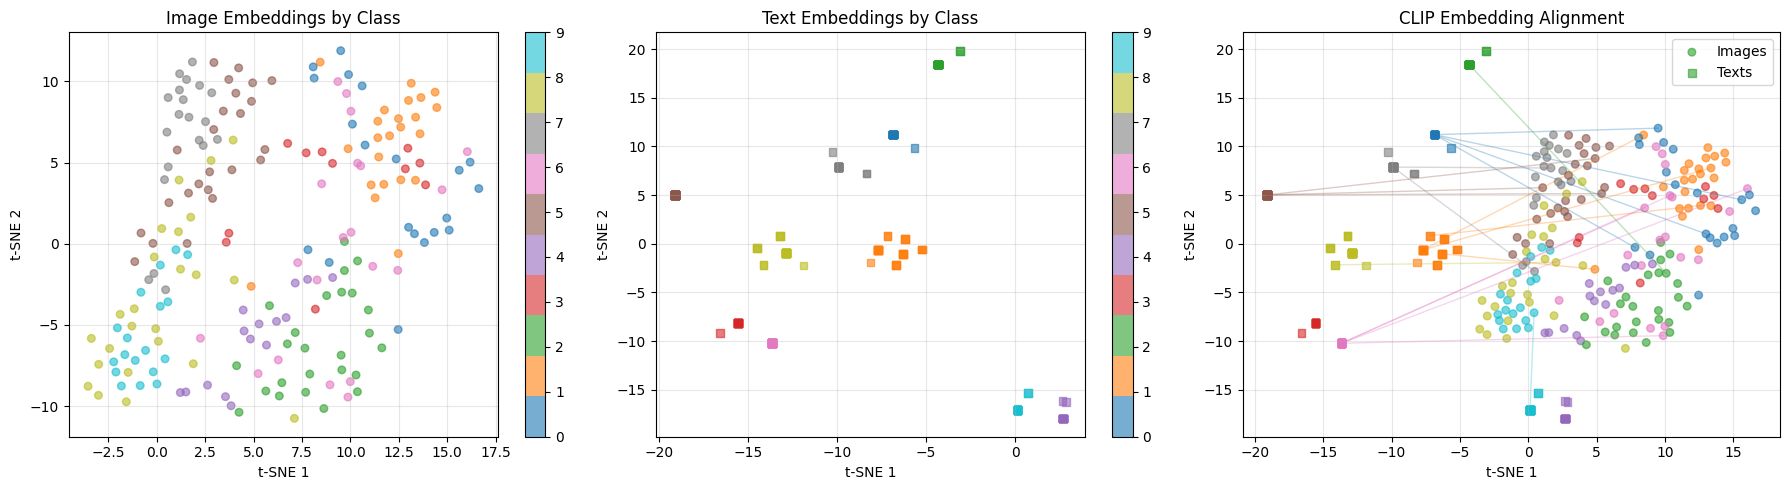

Cross-modal Similarity Statistics:
Mean similarity (matching pairs): 0.1525
Std similarity (matching pairs): 0.0113
Min similarity: 0.1017
Max similarity: 0.1876
Similarity by Class:
- T-shirt/top    : 0.1532 ± 0.0031
- Trouser        : 0.1487 ± 0.0032
- Pullover       : 0.1521 ± 0.0070
- Dress          : 0.1438 ± 0.0067
- Coat           : 0.1580 ± 0.0089
- Sandal         : 0.1531 ± 0.0041
- Shirt          : 0.1385 ± 0.0085
- Sneaker        : 0.1510 ± 0.0018
- Bag            : 0.1503 ± 0.0106
- Ankle boot     : 0.1768 ± 0.0082
Zero-shot Accuracy: 38.62%
Average image-text similarity: 0.1525


In [ ]:
clip_embeddings = visualize_clip_embeddings(
    trained_clip_model,
    clip_test_loader,
    tokenizer,
    device,
    num_samples=200
)

print(f"Zero-shot Accuracy: {clip_accuracy*100:.2f}%")
print(f"Average image-text similarity: {np.diag(clip_embeddings['similarities']).mean():.4f}")

In [ ]:
from datetime import datetime
from dateutil import tz

current_time = datetime.now(tz.gettz('Etc/GMT-3'))
print(f"Current time in UTC+3: {current_time}")

Current time in UTC+3: 2025-12-24 17:00:10.633961+03:00


**Лабораторная работа выполнена в рамках курса "Машинное обучение" ИТМО, 2025**